In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Step 1: Load the data
df = pd.read_csv('train.csv', header=None)

Step1: Which columns with a missing value percentage greater than 50%, we dropped from the DataFrame using the drop() method.

In [3]:
df.shape

(246008, 122)

In [4]:
df.isnull().sum().sum()

7318445

In [5]:
# Step 2: Drop columns with high percentage of missing values
missing_percentages = df.isnull().sum() / len(df) * 100
high_missing_cols = missing_percentages[missing_percentages > 50].index
df = df.drop(columns=high_missing_cols)

In [6]:
df.shape

(246008, 81)

In [7]:
df.isnull().sum().sum()

1292273

In [8]:
df.columns = [str(x) for x in range(81)]
df

,0,1,2,3,4,5,6,7,8,9,...,71,72,73,74,75,76,77,78,79,80
0,69769,-946,N,Bus2,0,2,0.0,180000.0,No,0,...,0.9851,1.0,-4670,0.9851,0,Mard,0.0,0.3333,0,0
1,236977,-92,Y,Othr,0,3,NaN,135000.0,NaN,0,...,NaN,NaN,-1994,NaN,0,Mard,0.0,NaN,0,0
2,168821,-1646,N,Bus3,0,2,0.0,553500.0,No,0,...,0.9891,2.0,-2842,0.9891,0,Sind,0.0,0.3750,0,1
3,94708,-1651,N,Bus3,0,2,0.0,391500.0,No,0,...,0.9682,4.0,-1345,0.9682,0,Sind,0.0,0.0417,0,1
4,84556,-977,N,Rest,0,2,NaN,225000.0,NaN,0,...,NaN,NaN,-852,NaN,0,Sind,0.0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246003,248161,-595,N,Bus3,0,2,NaN,405000.0,NaN,0,...,NaN,NaN,-4420,NaN,0,Mard,0.0,NaN,0,0
246004,257069,-4334,N,Mede,0,2,0.0,225000.0,No,0,...,0.9881,4.0,-2561,0.9881,0,Sind,0.0,0.3333,0,0
246005,154350,365243,N,XNAA,0,2,0.0,234000.0,No,0,...,0.9712,1.0,-4636,0.9712,0,Cive,0.0,0.1667,0,0
246006,148183,365243,N,XNAA,0,3,0.0,810000.0,NaN,0,...,NaN,5.0,-4636,NaN,0,Mard,0.0,NaN,0,1


Step2: Using mean()to calculate the average of numerical columns' values and filling the missing values with the corresponding averages.

In [9]:
# Step 3: Fill missing values in numeric columns with mean

# Select columns with non-numeric data type
numeric_cols = df.select_dtypes(include=['int', 'float']).columns

# Select columns with missing values less than or equal to 50%
low_missing_cols = missing_percentages[missing_percentages <= 50].index.intersection(numeric_cols)

# Iterate over the selected columns and fill missing values with their respective mean value
for col in low_missing_cols:
    col_mean = df[col].mean()
    df[col].fillna(col_mean, inplace=True)

Step3: Selecting columns with missing values less than or equal to 50%. Then, missing values in numerical columns are filled with the mean of the related column, by using a For loop.

In [10]:
# Step 4: Fill missing values in non-numeric columns with mode

# Selecting columns with non-numeric data type
non_numeric_cols = df.select_dtypes(exclude=['int', 'float']).columns

# Iterating over the selected columns and checking for missing values
for col in non_numeric_cols:
    if df[col].isnull().sum() > 0:
        # Computing the frequency distribution of column values
        col_freq = df[col].value_counts(normalize=True)
        top_freq = col_freq.iloc[0]
        # Checking if the difference between the top two frequency values is less than 10%
        second_freq = col_freq.iloc[1] if len(col_freq) > 1 else 0
        if top_freq - second_freq < 0.1:

            # If the top two frequency values are close, fill the missing values with the two most frequent values
            top2_freq = col_freq.iloc[:2].sum()
            fill_values = col_freq.iloc[:2].index.tolist()
            df[col].fillna(pd.Series(np.random.choice(fill_values, size=len(df[col]))), inplace=True)
        else:
            
            # Otherwise, fill the missing values with the mode value
            col_mode = df[col].mode()[0]
            df[col].fillna(col_mode, inplace=True)

Here the selection of columns with the non-numeric data type computes the frequency distribution of column values and fills missing values either with the two most frequent values if the top two frequency values are close, or with the mode value if they are not.

In [11]:
# Step 5: Convert the last column into a binary label column
binary_label = pd.Series(np.where(df.iloc[:, -1].values == 'one', 1, 0), name='binary_label', index=df.index)
df.drop(columns=df.columns[-1], inplace=True)
df = pd.concat([df, binary_label], axis=1)

C:\Users\mertb\AppData\Local\Temp\ipykernel_3480\2691242572.py:2: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  binary_label = pd.Series(np.where(df.iloc[:, -1].values == 'one', 1, 0), name='binary_label', index=df.index)


we created a binary tag column with integer values (1 and 0), a common format for machine-learning tasks

In [12]:
# Check for missing values in the DataFrame and binary label column
print("Total number of missing values in DataFrame:", df.isnull().sum().sum())
print("Total number of missing values in binary label column:", binary_label.isnull().sum())
print(f"Non-numerical columns number is: {len(non_numeric_cols)}")
print(f"Numerical columns number is: {len(numeric_cols)}")
print(f"Total number of rows in the DataFrame: {len(df)}")
print(f"Total number of columns in the DataFrame: {len(df.columns)}")

Total number of missing values in DataFrame: 1097723
Total number of missing values in binary label column: 0
Non-numerical columns number is: 13
Numerical columns number is: 68
Total number of rows in the DataFrame: 246008
Total number of columns in the DataFrame: 81


In [13]:
# Compute pairwise correlation of columns
corr_matrix = df.corr()

# Print the correlation matrix
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
corr_matrix

#The table shows the pairwise correlation matrix between each column of the DataFrame. 

C:\Users\mertb\AppData\Local\Temp\ipykernel_3480\955797988.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df.corr()


,0,1,4,5,6,7,9,11,12,13,14,15,16,17,18,19,22,23,24,25,26,27,28,29,31,32,34,35,36,37,38,39,40,41,42,43,44,47,48,49,50,51,52,53,54,55,56,57,58,59,61,62,63,64,65,67,68,69,70,71,72,73,74,75,77,78,79,binary_label
0,1.000000,0.002158,0.000674,0.000783,-0.004490,0.001684,-0.003079,0.001971,-0.002175,0.000882,0.000555,-0.000904,0.002698,-0.001347,0.000125,0.002055,-0.001392,-0.000075,-0.001416,0.000876,0.002362,0.003104,-0.002523,-0.002799,-0.002990,0.000586,-0.000180,-0.000089,0.001402,0.001175,0.001242,0.000693,-0.001874,-0.001987,0.000300,-0.000177,0.001681,-0.001941,-0.001425,-0.000354,0.000445,0.002961,0.002577,-0.005233,-0.003113,0.003117,0.002227,0.002179,0.000772,-0.000472,-0.001563,0.000403,-0.002058,0.000597,0.001079,-0.002172,-0.000293,-0.001516,0.002524,-0.005636,-0.003547,-0.002063,-0.005459,-0.003278,-0.001358,0.002231,-0.000061,NaN
1,0.002158,1.000000,-0.024953,0.034254,-0.034954,-0.063078,-0.013680,-0.008204,0.014949,0.000023,-0.233663,-0.021017,-0.028657,0.005724,-0.095968,0.597597,0.000913,-0.004177,0.005522,0.032502,-0.015104,-0.102090,-0.090335,0.013125,0.021062,-0.006711,-0.218204,-0.107354,-0.003793,-0.035140,-0.058388,0.113765,-0.062484,-0.210510,-0.249387,-0.010267,-0.065029,-0.614650,-0.254414,0.013857,-0.240020,0.000765,-0.003150,0.008383,-0.041026,0.002347,-0.015847,0.023538,-0.014670,0.000666,-0.009965,-0.000983,-0.090215,-0.233579,-0.023313,-0.999735,-0.023745,-0.019947,-0.043021,0.008217,0.049851,-0.272141,0.008394,-0.001019,0.016974,-0.015857,-0.121515,NaN
4,0.000674,-0.024953,1.000000,-0.033737,0.010844,0.052609,-0.002018,0.006771,0.006583,-0.000551,0.000677,0.023740,-0.003629,-0.004507,0.019291,-0.017321,0.000117,-0.002732,-0.004354,-0.032955,0.028206,0.027232,0.024471,-0.063778,-0.005019,-0.000917,-0.001103,0.015077,0.032218,0.005471,0.021965,-0.001951,-0.004904,0.015347,-0.021627,-0.001439,0.052701,0.026591,-0.000869,-0.008695,0.002681,-0.000235,-0.000390,-0.000022,-0.005277,-0.007486,0.029637,0.022345,0.023489,0.004635,0.036125,-0.000797,0.000834,0.003663,-0.003169,0.025056,0.000901,-0.007216,-0.005861,-0.000059,-0.033793,0.003315,0.000378,-0.000117,-0.009139,0.029927,0.078427,NaN
5,0.000783,0.034254,-0.033737,1.000000,-0.067400,-0.112467,-0.008946,-0.002476,-0.078465,-0.005724,0.014799,-0.288469,-0.013675,0.030664,-0.141438,0.020044,0.000126,0.006202,0.031010,0.951187,-0.236333,-0.141823,-0.265735,0.012056,0.007442,-0.005095,-0.002882,-0.133406,-0.531791,-0.039116,-0.083595,-0.011170,-0.051188,0.074057,0.065856,-0.002202,-0.111346,0.007966,0.028258,0.018572,0.024932,-0.002258,-0.000419,-0.000873,-0.012962,0.000535,-0.247215,0.026108,-0.177857,-0.000050,0.000396,0.000327,0.045812,0.030786,-0.038444,-0.034328,-0.038241,-0.015577,-0.006947,-0.000740,0.012346,-0.005486,-0.000887,-0.000126,0.015133,-0.250451,-0.087137,NaN
6,-0.004490,-0.034954,0.010844,-0.067400,1.000000,0.056136,0.002248,-0.003623,0.032057,0.006388,-0.002315,0.052273,-0.001522,0.001001,0.010573,-0.024757,NaN,0.000285,0.000827,-0.069019,0.046604,0.039085,0.037672,0.007031,-0.012063,-0.000539,-0.007603,0.009775,0.078760,0.002208,0.022829,-0.008575,0.025878,-0.010066,0.010572,-0.002744,0.053811,0.001955,-0.011674,-0.004234,-0.010851,0.001100,NaN,-0.001164,0.000585,-0.013329,0.048601,-0.039709,0.035368,-0.004294,0.001096,-0.003062,-0.009626,-0.007390,0.004782,0.034606,0.004251,0.006695,0.001014,-0.000807,-0.003586,-0.008523,-0.000980,-0.000631,-0.001979,0.049428,0.019332,NaN
7,0.001684,-0.063078,0.052609,-0.112467,0.056136,1.000000,0.032023,-0.014715,0.042178,0.002396,-0.001652,0.140484,0.035880,0.000181,0.054016,-0.049667,0.001564,-0.002482,0.000110,-0.103763,0.105676,0.775310,0.061746,0.020516,0.019359,0.007514,-0.001816,0.053525,0.105155,0.026266,0.146198,0.049937,0.019024,0.011866,0.074865,0.021276,0.987000,-0.055318,-0.021216,-0.025387,-0.001731,-0.001122,0.011472,0.007144,0.030688,-0.000845,0.108679,-0.076344,0.078439,0.005256,0.031848,-0.000193,-0.027097,0.062183,0.049465,0.061702,0.024912,-0.005998,0.060041,0.006630,-0.051085,-0.00

Some details about the data. Binary_label is already non-numerical, so it is NaN value for here.

C:\Users\mertb\AppData\Local\Temp\ipykernel_3480\3367517515.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()


<Axes: >

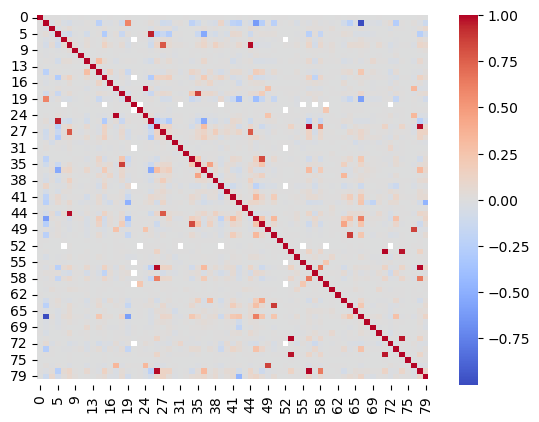

In [14]:
# Compute correlation matrix
corr = df.corr()

# Generate heatmap
sns.heatmap(corr, cmap='coolwarm')

This corelation information can be useful in feature selection, identifying multicollinearity, and understanding the relationships between variables in the dataset.

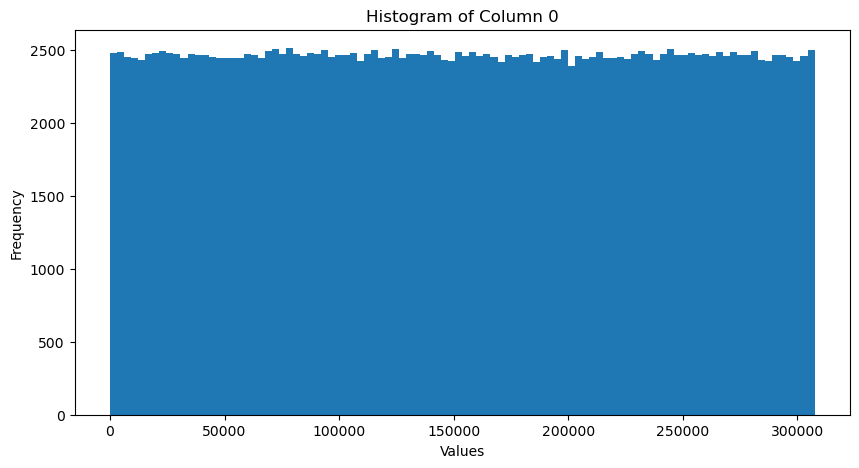

In [15]:
# Select the first numerical column
num_col = df.iloc[:, 0]

# Plot a histogram
plt.figure(figsize=(10,5))
plt.hist(num_col, bins=100)
plt.title('Histogram of Column 0')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

Column 0 is a unique data, and has a uniform of distrubution.

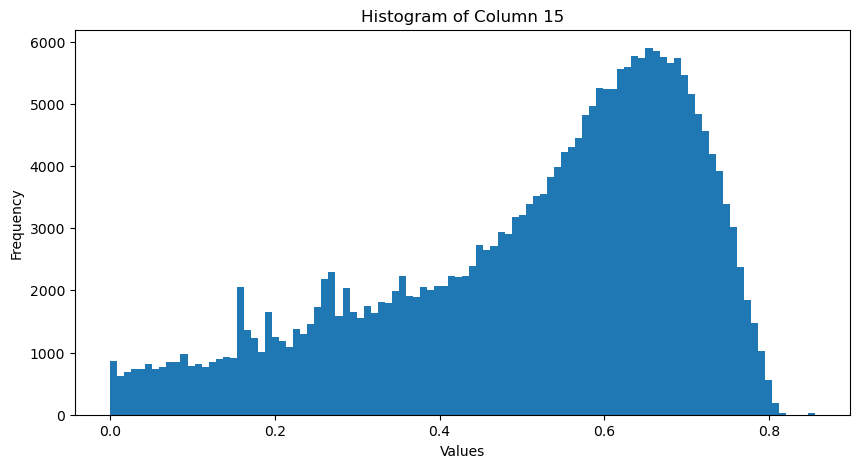

In [16]:
num_col = df.iloc[:, 15]

# Plot a histogram
plt.figure(figsize=(10,5))
plt.hist(num_col, bins=100)
plt.title('Histogram of Column 15')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

As we can see this column 15 is right skewed 

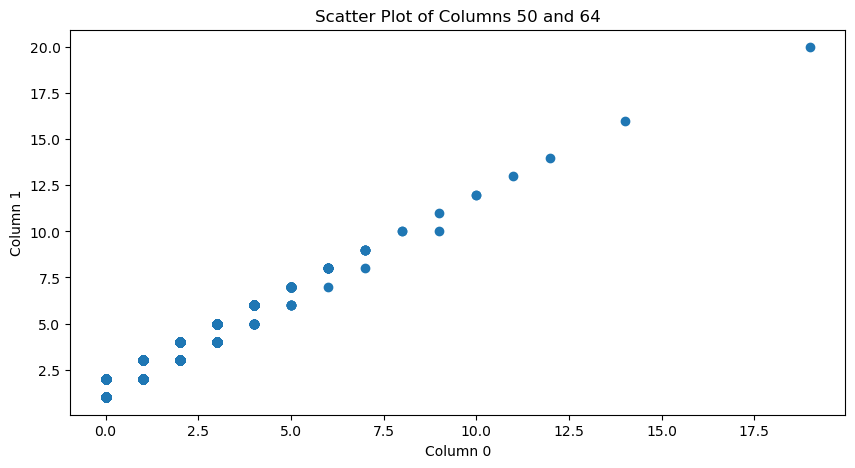

In [17]:
num_col1 = df.iloc[:, 50]
num_col2 = df.iloc[:, 64]

# Plot a scatter plot
plt.figure(figsize=(10,5))
plt.scatter(num_col1, num_col2)
plt.title('Scatter Plot of Columns 50 and 64')
plt.xlabel('Column 0')
plt.ylabel('Column 1')
plt.show()

In Column 50 and 64 there is a positive correlation

<Axes: >

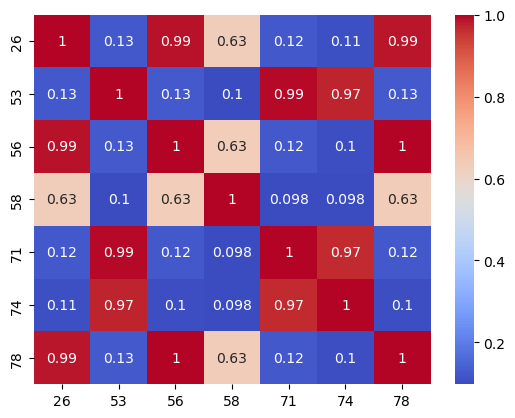

In [18]:
rel_cols =df[['26','53','56','58','71','74','78']].corr()
sns.heatmap(rel_cols, cmap='coolwarm', annot=True)

These Columns mostly have 0's and 1's. So there is also a positive and negative correlations which we can use.